# SAXS Data Creation

This script implements the code from https://github.com/andreashlarsen/Shape2SAS to simulates small-angle x-ray scattering (SAXS) from user-defined shapes. 

This code is executed in a specific environment specified in https://github.com/andreashlarsen/Shape2SAS/blob/main/README.md under the installation subsection. It is important to execute in this environment for reproducibility reasons.

Note for myself: Open anaconda prompt and run "conda activate shape2sas_env" to activate environment.

In [10]:
import numpy as np
import matplotlib
import scipy
import fast_histogram
import torch

from pathlib import Path
import os
import sys
import runpy
print(torch.__version__)

checks = [
    np.__version__ == "1.26.0",
    matplotlib.__version__ == "3.8.0",
    scipy.__version__ == "1.12.0",
    fast_histogram.__version__ == "0.12",
    torch.__version__ == "2.11.0+cpu"
]
if all(checks):
        print("All library versions are correct.")
else:
    print("Used library versions are not correct.")


2.11.0+cpu
All library versions are correct.


Note: I have chosen to make the length of the all the output arrays to a multiple of 256 (in this case 512) in order to be able to input it later on in gnnom to calculate dmax.

The subsequent cell can be exchanged for another cell from the "Bookkeeping scripts data creation" ipynb file, in order to model the other shapes. 

In [2]:




from pathlib import Path
import os
import sys
import runpy
import numpy as np

# folder that contains shape2sas.py, shape2sas_helpfunctions.py, and subunits/
workdir = Path.cwd()
os.chdir(workdir)
sys.path.insert(0, str(workdir))

# number of rings
n_samples = 1000

rng = np.random.default_rng(42)

# parameter ranges
outer_radius_min = 30.0
outer_radius_max = 300.0

inner_radius_min = 5.0
inner_radius_max = 250.0

length_min = 20.0
length_max = 500.0

# stratified sampling
u1 = (np.arange(n_samples) + rng.random(n_samples)) / n_samples
u2 = (np.arange(n_samples) + rng.random(n_samples)) / n_samples
u3 = (np.arange(n_samples) + rng.random(n_samples)) / n_samples

rng.shuffle(u1)
rng.shuffle(u2)
rng.shuffle(u3)

# generate parameters
outer_radius_values = (
    outer_radius_min
    + u1 * (outer_radius_max - outer_radius_min)
)

inner_radius_values = (
    inner_radius_min
    + u2 * (inner_radius_max - inner_radius_min)
)

length_values = (
    length_min
    + u3 * (length_max - length_min)
)

# enforce inner_radius < outer_radius
inner_radius_values = np.minimum(
    inner_radius_values,
    outer_radius_values - 1.0
)

# avoid nonphysical geometry
inner_radius_values = np.clip(
    inner_radius_values,
    1.0,
    None
)

# model labels
model_labels = np.array(
    ["ring"] * n_samples,
    dtype="<U32"
)

# store rows here
q_rows = []

Iq_rows = []
Isim_rows = []
sigma_rows = []

r_rows = []
pr_rows = []

dmax_rows = []

for r_outer, r_inner, length in zip(
    outer_radius_values,
    inner_radius_values,
    length_values
):

    model_name = (
        f"ring_ro_{r_outer:.2f}"
        f"_ri_{r_inner:.2f}"
        f"_l_{length:.2f}"
    )

    sys.argv = [
        "shape2sas.py",

        "-s", "ring",

        "-d",
        (
            f"{r_outer:.6f},"
            f"{r_inner:.6f},"
            f"{length:.6f}"
        ),

        "-m",
        model_name
    ]

    ns = runpy.run_path(
        "shape2sas.py",
        run_name="__main__"
    )

    # computed outputs
    q = np.asarray(ns["q_array"])

    Iq = np.asarray(ns["Iq_array"])

    Isim = np.asarray(ns["Isim_array"])

    sigma = np.asarray(ns["sigma_array"])

    r = np.asarray(ns["r_array"])

    pr = np.asarray(ns["pr_array"])

    # maximum dimension
    dmax = np.max(r)

    # append rows
    q_rows.append(q)

    Iq_rows.append(Iq)

    Isim_rows.append(Isim)

    sigma_rows.append(sigma)

    r_rows.append(r)

    pr_rows.append(pr)

    dmax_rows.append(dmax)

# stack into matrices
q_matrix = np.vstack(q_rows)

Iq_matrix = np.vstack(Iq_rows)

Isim_matrix = np.vstack(Isim_rows)

sigma_matrix = np.vstack(sigma_rows)

r_matrix = np.vstack(r_rows)

pr_matrix = np.vstack(pr_rows)

dmax_array = np.asarray(dmax_rows)

# normalized r grid
r_grid_row = np.linspace(0.0, 1.0, 512)

r_grid_matrix = np.tile(
    r_grid_row,
    (n_samples, 1)
)

# print shapes
print("q_matrix:", q_matrix.shape)

print("Iq_matrix:", q_matrix.shape)

print("Isim_matrix:", Isim_matrix.shape)

print("sigma_matrix:", sigma_matrix.shape)

print("r_matrix:", r_matrix.shape)

print("pr_matrix:", pr_matrix.shape)

print("dmax_array:", dmax_array.shape)

print("r_grid_matrix:", r_grid_matrix.shape)

print("model_labels:", model_labels.shape)

# save everything
np.savez_compressed(
    "saxs_training_data_ring.npz",

    # model labels
    model_labels=model_labels,

    # geometry parameters
    outer_radius_values=outer_radius_values,

    inner_radius_values=inner_radius_values,

    length_values=length_values,

    # scattering data
    q_matrix=q_matrix,

    Iq_matrix=Iq_matrix,

    Isim_matrix=Isim_matrix,

    sigma_matrix=sigma_matrix,

    r_matrix=r_matrix,

    pr_matrix=pr_matrix,

    # max dimension
    dmax_array=dmax_array,

    # normalized r-grid
    r_grid_matrix=r_grid_matrix
)

print("\nSaved:")
print("saxs_training_data_ring.npz")




        8025 points for subunit 0: ring
             Point density     : 1.756e-04 (points per volume)
             Scattering density: 1.756e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8025 (non-overlapping region)
        Total points in model: 8025
        Total volume of model: 4.570e+07 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 5.302e+02 A
           Rg  : 1.794e+02 A
        7970 points for subunit 0: ring
             Point density     : 5.354e-02 (points per volume)
             Scattering density: 5.354e-02 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7970 (non-overlapping region)
        Total points in model: 7970
        Total volume of model: 1.489e+05 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)..

        calculating p(r)...
           dmax: 6.277e+02 A
           Rg  : 2.104e+02 A
        7947 points for subunit 0: ring
             Point density     : 3.325e-02 (points per volume)
             Scattering density: 3.325e-02 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7947 (non-overlapping region)
        Total points in model: 7947
        Total volume of model: 2.390e+05 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 3.128e+02 A
           Rg  : 1.390e+02 A
        7946 points for subunit 0: ring
             Point density     : 3.397e-02 (points per volume)
             Scattering density: 3.397e-02 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7946 (non-overlapping region)
        Total points in model: 7946
        Total volume of model: 2.339e+05 A^3
 
      

        calculating p(r)...
           dmax: 5.168e+02 A
           Rg  : 1.785e+02 A
        7933 points for subunit 0: ring
             Point density     : 7.752e-04 (points per volume)
             Scattering density: 7.752e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7933 (non-overlapping region)
        Total points in model: 7933
        Total volume of model: 1.023e+07 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 3.947e+02 A
           Rg  : 1.246e+02 A
        7955 points for subunit 0: ring
             Point density     : 3.388e-02 (points per volume)
             Scattering density: 3.388e-02 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7955 (non-overlapping region)
        Total points in model: 7955
        Total volume of model: 2.348e+05 A^3
 
      

        calculating p(r)...
           dmax: 5.264e+02 A
           Rg  : 1.684e+02 A
        8130 points for subunit 0: ring
             Point density     : 8.110e-02 (points per volume)
             Scattering density: 8.110e-02 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8130 (non-overlapping region)
        Total points in model: 8130
        Total volume of model: 1.002e+05 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 2.540e+02 A
           Rg  : 1.075e+02 A
        8066 points for subunit 0: ring
             Point density     : 9.954e-04 (points per volume)
             Scattering density: 9.954e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8066 (non-overlapping region)
        Total points in model: 8066
        Total volume of model: 8.103e+06 A^3
 
      

        calculating p(r)...
           dmax: 2.347e+02 A
           Rg  : 7.797e+01 A
        8084 points for subunit 0: ring
             Point density     : 2.581e-03 (points per volume)
             Scattering density: 2.581e-03 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8084 (non-overlapping region)
        Total points in model: 8084
        Total volume of model: 3.132e+06 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 4.817e+02 A
           Rg  : 2.256e+02 A
        7996 points for subunit 0: ring
             Point density     : 1.276e-04 (points per volume)
             Scattering density: 1.276e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7996 (non-overlapping region)
        Total points in model: 7996
        Total volume of model: 6.266e+07 A^3
 
      

...

        calculating p(r)...
           dmax: 3.742e+02 A
           Rg  : 1.670e+02 A
        7985 points for subunit 0: ring
             Point density     : 1.799e-03 (points per volume)
             Scattering density: 1.799e-03 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7985 (non-overlapping region)
        Total points in model: 7985
        Total volume of model: 4.439e+06 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 2.722e+02 A
           Rg  : 9.939e+01 A
        8104 points for subunit 0: ring
             Point density     : 2.456e-01 (points per volume)
             Scattering density: 2.456e-01 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8104 (non-overlapping region)
        Total points in model: 8104
        Total volume of model: 3.300e+04 A^3
 
      

        calculating p(r)...
           dmax: 5.180e+02 A
           Rg  : 1.879e+02 A
        7997 points for subunit 0: ring
             Point density     : 1.495e-03 (points per volume)
             Scattering density: 1.495e-03 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7997 (non-overlapping region)
        Total points in model: 7997
        Total volume of model: 5.348e+06 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 5.471e+02 A
           Rg  : 2.501e+02 A
        8053 points for subunit 0: ring
             Point density     : 2.091e-04 (points per volume)
             Scattering density: 2.091e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8053 (non-overlapping region)
        Total points in model: 8053
        Total volume of model: 3.852e+07 A^3
 
      

        calculating p(r)...
           dmax: 5.174e+02 A
           Rg  : 2.072e+02 A
        7922 points for subunit 0: ring
             Point density     : 1.640e-04 (points per volume)
             Scattering density: 1.640e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7922 (non-overlapping region)
        Total points in model: 7922
        Total volume of model: 4.831e+07 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 7.073e+02 A
           Rg  : 2.673e+02 A
        8045 points for subunit 0: ring
             Point density     : 3.782e-04 (points per volume)
             Scattering density: 3.782e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8045 (non-overlapping region)
        Total points in model: 8045
        Total volume of model: 2.127e+07 A^3
 
      

        calculating p(r)...
           dmax: 4.166e+02 A
           Rg  : 1.403e+02 A
        7978 points for subunit 0: ring
             Point density     : 7.630e-04 (points per volume)
             Scattering density: 7.630e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7978 (non-overlapping region)
        Total points in model: 7978
        Total volume of model: 1.046e+07 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 3.364e+02 A
           Rg  : 1.099e+02 A
        8120 points for subunit 0: ring
             Point density     : 6.139e-04 (points per volume)
             Scattering density: 6.139e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 8120 (non-overlapping region)
        Total points in model: 8120
        Total volume of model: 1.323e+07 A^3
 
      

        calculating p(r)...
           dmax: 3.815e+02 A
           Rg  : 1.296e+02 A
        7978 points for subunit 0: ring
             Point density     : 3.628e-04 (points per volume)
             Scattering density: 3.628e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7978 (non-overlapping region)
        Total points in model: 7978
        Total volume of model: 2.199e+07 A^3
 
        calculating distances...
        calculating contrasts...
        calculating p(r)...
           dmax: 4.615e+02 A
           Rg  : 1.737e+02 A
        7903 points for subunit 0: ring
             Point density     : 6.276e-04 (points per volume)
             Scattering density: 6.276e-04 (density times scattering length)
             Excluded points   : 0 (overlap region)
             Remaining points  : 7903 (non-overlapping region)
        Total points in model: 7903
        Total volume of model: 1.259e+07 A^3
 
      

In [3]:
print(Iq_matrix)

[[9.89327220e-01 9.58870365e-01 9.10234081e-01 ... 8.57261768e-07
  6.81478446e-07 4.59041668e-07]
 [9.99158763e-01 9.96717183e-01 9.92685245e-01 ... 8.34331987e-05
  8.14269043e-05 7.97745164e-05]
 [9.98319839e-01 9.93449903e-01 9.85429091e-01 ... 3.86975590e-04
  3.40822314e-04 2.96274656e-04]
 ...
 [9.95759897e-01 9.83527137e-01 9.63565053e-01 ... 1.10489564e-03
  1.12258648e-03 1.17035853e-03]
 [9.88571523e-01 9.56000641e-01 9.04128206e-01 ... 1.98051641e-05
  2.84738960e-05 5.36064714e-05]
 [9.82470477e-01 9.32956387e-01 8.55499292e-01 ... 2.35166873e-05
  4.15712129e-05 6.16419181e-05]]


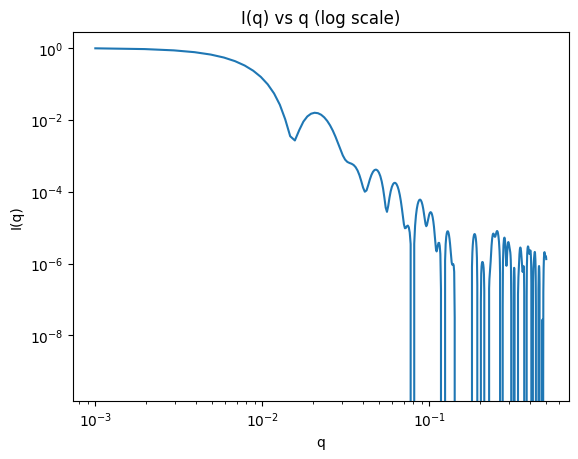

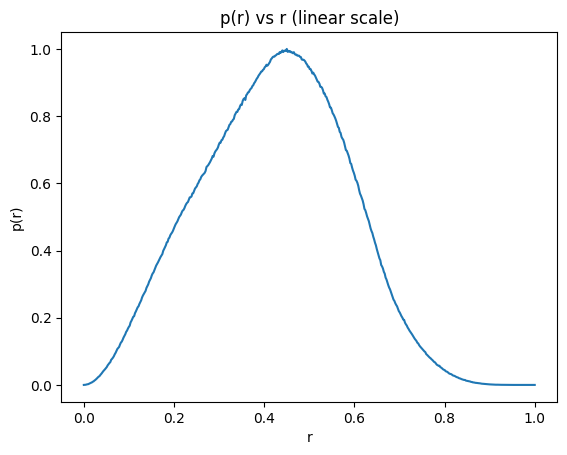

In [4]:
import matplotlib.pyplot as plt
uniqueindex = 900
# Select second entry (index 1)
q = q_matrix[uniqueindex]
Iq = Iq_matrix[uniqueindex]
r = r_grid_matrix[uniqueindex]
pr = pr_matrix[uniqueindex]

# --- Plot I(q) vs q (log scale) ---
plt.figure()
plt.plot(q, Iq)
plt.yscale('log')  # log scale on intensity
plt.xscale('log')
plt.xlabel('q')
plt.ylabel('I(q)')
plt.title('I(q) vs q (log scale)')
plt.show()

# --- Plot p(r) vs r (linear scale) ---
plt.figure()
plt.plot(r, pr)
plt.xlabel('r')
plt.ylabel('p(r)')
plt.title('p(r) vs r (linear scale)')
plt.show()

Saving the arrays as .npz for optimal performance. The data will then later on be imported in the machine learning script. \
The subsequent cell can be exchanged for another cell from the "Bookkeeping scripts data creation" ipynb file, in order to save the other shapes. 

In [5]:
'''
np.savez_compressed(
    "saxs_training_data_superellipsoid.npz",

    equator_radius_values=equator_radius_values,
    eccentricity_values=eccentricity_values,
    shape_t_values=shape_t_values,
    shape_s_values=shape_s_values,

    q_matrix=q_matrix,
    Iq_matrix=Iq_matrix,
    r_matrix=r_matrix,
    pr_matrix=pr_matrix,

    dmax_array=dmax_array,

    r_grid_matrix=r_grid_matrix
)


'''

'\nnp.savez_compressed(\n    "saxs_training_data_superellipsoid.npz",\n\n    equator_radius_values=equator_radius_values,\n    eccentricity_values=eccentricity_values,\n    shape_t_values=shape_t_values,\n    shape_s_values=shape_s_values,\n\n    q_matrix=q_matrix,\n    Iq_matrix=Iq_matrix,\n    r_matrix=r_matrix,\n    pr_matrix=pr_matrix,\n\n    dmax_array=dmax_array,\n\n    r_grid_matrix=r_grid_matrix\n)\n\n\n'

In [6]:
# Validity check
print("Iq_matrix has non-finite:", ~np.isfinite(Iq_matrix).all())
print("pr_matrix has non-finite:", ~np.isfinite(pr_matrix).all())

print("Iq_matrix min/max (safe):", np.nanmin(Iq_matrix), np.nanmax(Iq_matrix))
print("pr_matrix min/max (safe):", np.nanmin(pr_matrix), np.nanmax(pr_matrix))

Iq_matrix has non-finite: False
pr_matrix has non-finite: False
Iq_matrix min/max (safe): -1.694798015893758e-05 0.9996664241014086
pr_matrix min/max (safe): 0.0 1.0
